# 7 · Patch SVDD

**Motivation:** Standard image-level SVDD compresses a full 256×256 image into a single embedding.  
A crack typically occupies ~5% of pixels — its signal is diluted in the global representation.  
Patch SVDD (Yi & Yoon, ACCV 2021) instead operates at patch level:

- Each image is divided into overlapping 64×64 patches
- SVDD is trained on **patch embeddings** from normal images only
- At test time, each patch gets a distance score → **max score = image anomaly score**
- A single anomalous patch (containing a crack) is enough to flag the whole image

**Two encoder variants compared:**

| Variant | Encoder | Pretrained? |
|---------|---------|-------------|
| Scratch | Lightweight CNN (3→32→64→128) | ✗ Random init |
| Pretrained | ResNet18 (frozen early layers) | ✓ ImageNet |

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score

from src.dataset import load_splits
from src.train_utils import compute_metrics, calibrate_threshold

SPLITS_DIR      = 'splits'
RESULTS_DIR     = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

PATCH_SIZE      = 64
STRIDE          = 32
MAX_TRAIN_IMG   = 1000    # image tensors cached in RAM (~1.2 GB), not patches
EMBED_DIM       = 128
EPOCHS          = 30
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
BATCH_SIZE      = 256
SPREAD_LAM      = 1.0     # spread regularisation weight
RANDOM_STATE    = 42

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'Patch  : {PATCH_SIZE}×{PATCH_SIZE}, stride {STRIDE}')
print(f'Patches per image (approx): {((256 - PATCH_SIZE) // STRIDE + 1) ** 2}')

Device : cuda
Patch  : 64×64, stride 32
Patches per image (approx): 49


### 2. Patch Dataset

In [ ]:
# Standard ImageNet normalisation
_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])


def extract_patches(img_tensor: torch.Tensor,
                    patch_size: int = PATCH_SIZE,
                    stride: int = STRIDE) -> torch.Tensor:
    
    C, H, W = img_tensor.shape
    patches = []
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            patches.append(img_tensor[:, y:y+patch_size, x:x+patch_size])
    return torch.stack(patches)   # (N, C, P, P)


class PatchTrainDataset(Dataset):
    """Patch dataset — caches image tensors in RAM, extracts patches on-the-fly.

    Strategy: load and transform MAX_TRAIN_IMG images once at init (~1.2 GB),
    then slice patches in __getitem__ with no disk I/O during training.

    Memory: 1000 images × 3 × 256 × 256 × 4 bytes ≈ 786 MB
    vs pre-loading patches: 1000 × 49 × 3 × 64 × 64 × 4 bytes ≈ 2.4 GB
    """
    def __init__(self, records, max_images=MAX_TRAIN_IMG,
                 patch_size=PATCH_SIZE, stride=STRIDE, seed=RANDOM_STATE):
        rng    = np.random.default_rng(seed)
        normal = [r for r in records if r['label'] == 0]
        if len(normal) > max_images:
            idx    = rng.choice(len(normal), size=max_images, replace=False)
            normal = [normal[i] for i in idx]

        self.patch_size = patch_size
        self.stride     = stride

        # Cache image tensors in RAM
        print(f'  Loading {len(normal)} images into RAM...')
        self.images = []
        for rec in normal:
            img = Image.open(rec['image_path']).convert('RGB')
            self.images.append(_transform(img))   # (C, H, W) tensor

        # Pre-compute patch coordinates
        self.coords = []
        for img_idx in range(len(self.images)):
            for y in range(0, 256 - patch_size + 1, stride):
                for x in range(0, 256 - patch_size + 1, stride):
                    self.coords.append((img_idx, y, x))

        print(f'  Images cached  : {len(self.images):,}')
        print(f'  Total patches  : {len(self.coords):,}')

    def __len__(self): return len(self.coords)

    def __getitem__(self, i):
        img_idx, y, x = self.coords[i]
        return self.images[img_idx][:, y:y+self.patch_size, x:x+self.patch_size]


class ImageEvalDataset(Dataset):
    """Returns full images + labels for evaluation.
    Patches are extracted on-the-fly during scoring.
    """
    def __init__(self, records):
        self.records = records

    def __len__(self): return len(self.records)

    def __getitem__(self, i):
        rec = self.records[i]
        img = Image.open(rec['image_path']).convert('RGB')
        t   = _transform(img)
        return t, rec['label']


# Load splits
train_records, val_records, test_records = load_splits(SPLITS_DIR)

print('Building patch training dataset...')
train_patch_ds = PatchTrainDataset(train_records)
train_loader   = DataLoader(train_patch_ds, batch_size=BATCH_SIZE,
                            shuffle=True, num_workers=0)

val_ds   = ImageEvalDataset(val_records)
test_ds  = ImageEvalDataset(test_records)
val_loader  = DataLoader(val_ds,  batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

print(f'Val images : {len(val_ds):,}  |  Test images : {len(test_ds):,}')

Building patch training dataset...
  Loading 1000 images into RAM...
  Images cached  : 1,000
  Total patches  : 49,000
Val images : 3,650  |  Test images : 3,651


### 3. Shared Utilities + Variant A: Scratch CNN Encoder

In [3]:
class PatchEncoder(nn.Module):
    """Variant A — Lightweight scratch CNN encoder for 64×64 patches.

    Architecture: three conv blocks → global average pool → linear projection.
    No pretrained weights — learns patch texture from scratch.
    bias=False throughout to prevent the SVDD bias-collapse shortcut.
    """
    def __init__(self, embed_dim: int = EMBED_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            # Block 1: 64×64 → 32×32
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2: 32×32 → 16×16
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 16×16 → 8×8
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Global average pool → (B, 128)
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        # Projection head — bias=False to prevent trivial solution
        self.head = nn.Linear(128, embed_dim, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.encoder(x))


def init_centre(model: nn.Module,
                loader: DataLoader,
                device: torch.device,
                eps: float = 0.1) -> torch.Tensor:
    """Compute centre c as mean of patch embeddings over training set.
    Clamps near-zero components to avoid degenerate centre.
    """
    model.eval()
    zs = []
    with torch.no_grad():
        for x in loader:
            zs.append(model(x.to(device)))
    c = torch.cat(zs, dim=0).mean(dim=0)
    c[(c.abs() < eps) & (c >= 0)] =  eps
    c[(c.abs() < eps) & (c <  0)] = -eps
    print(f'Centre norm : {c.norm().item():.4f}')
    return c.detach()


def patch_svdd_scores(model: nn.Module,
                      c: torch.Tensor,
                      loader: DataLoader,
                      device: torch.device,
                      patch_size: int = PATCH_SIZE,
                      stride: int = STRIDE) -> tuple:
    """Compute image-level anomaly scores using max patch distance."""
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            for i in range(imgs.size(0)):
                patches = extract_patches(imgs[i], patch_size, stride).to(device)
                z       = model(patches)
                dists   = ((z - c) ** 2).sum(dim=1)
                score   = dists.max().item()
                all_scores.append(score)
                all_labels.append(labels[i].item())
    return np.array(all_scores), np.array(all_labels)


def train_patch_svdd(model, train_loader, val_loader, device,
                     epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
                     spread_lam=SPREAD_LAM, save_path=None, label=''):
    """Generic Patch SVDD training loop with spread regularisation."""
    c         = init_centre(model, train_loader, device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_losses, val_aurocs = [], []
    best_auroc, best_epoch   = 0.0, 0

    print(f'Training {label} (spread λ={spread_lam}) for {epochs} epochs...')
    print(f'{"Epoch":>6}  {"Loss":>8}  {"Val AUROC":>10}')
    print('-' * 30)

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for x in train_loader:
            x         = x.to(device)
            z         = model(x)
            svdd_loss = ((z - c) ** 2).sum(dim=1).mean()
            spread    = z.std(dim=0).mean()
            loss      = svdd_loss - spread_lam * spread
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += svdd_loss.item()
        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        if epoch % 5 == 0 or epoch == 1:
            scores, labels = patch_svdd_scores(model, c, val_loader, device)
            auroc = roc_auc_score(labels, scores) if labels.sum() > 0 else 0.0
            val_aurocs.append((epoch, auroc))
            marker = ' ★' if auroc > best_auroc else ''
            if auroc > best_auroc:
                best_auroc, best_epoch = auroc, epoch
                if save_path:
                    torch.save({'model_state': model.state_dict(), 'centre': c}, save_path)
            print(f'{epoch:>6}  {avg_loss:>8.4f}  {auroc:>10.4f}{marker}')
        else:
            print(f'{epoch:>6}  {avg_loss:>8.4f}')

    print(f'Done. Best val AUROC: {best_auroc:.4f} at epoch {best_epoch}')
    return c, train_losses, val_aurocs, best_auroc


# ── Instantiate Variant A ────────────────────────────────────────────────────
model_scratch = PatchEncoder(embed_dim=EMBED_DIM).to(device)
print('Variant A — Scratch CNN')
print(f'  Params: {sum(p.numel() for p in model_scratch.parameters()):,}')

Variant A — Scratch CNN
  Params: 109,856


### 4. Train Variant A — Scratch CNN

In [4]:
c_scratch, losses_scratch, aurocs_scratch, best_scratch = train_patch_svdd(
    model_scratch, train_loader, val_loader, device,
    save_path=f'{RESULTS_DIR}/patch_svdd_scratch_best.pt',
    label='Patch SVDD (Scratch CNN)',
)

Centre norm : 1.1359
Training Patch SVDD (Scratch CNN) (spread λ=1.0) for 30 epochs...
 Epoch      Loss   Val AUROC
------------------------------
     1    0.5333      0.7280 ★
     2    0.0217
     3    0.0141
     4    0.0110
     5    0.0086      0.7109
     6    0.0072
     7    0.0063
     8    0.0052
     9    0.0051
    10    0.0048      0.7170
    11    0.0044
    12    0.0042
    13    0.0038
    14    0.0036
    15    0.0038      0.6593
    16    0.0033
    17    0.0030
    18    0.0029
    19    0.0029
    20    0.0029      0.6780
    21    0.0027
    22    0.0027
    23    0.0026
    24    0.0025
    25    0.0025      0.6892
    26    0.0025
    27    0.0024
    28    0.0023
    29    0.0023
    30    0.0023      0.6901
Done. Best val AUROC: 0.7280 at epoch 1


### 5. Variant B — Pretrained ResNet18 Patch Encoder

ResNet18 pretrained on ImageNet provides rich low-level texture features from the start.  
We freeze `layer1`+`layer2` and fine-tune `layer3`+`layer4` on patch SVDD.  
The global average pool output (512-d) is projected to `EMBED_DIM` via a bias-free head.

In [20]:
class PatchEncoderResNet(nn.Module):
    """Variant B — ResNet18 backbone for 64×64 patches.

    ResNet18 expects ≥32×32 input; 64×64 patches work fine.
    Freeze layer1+layer2, fine-tune layer3+layer4.
    bias=False on projection head.
    """
    def __init__(self, embed_dim: int = EMBED_DIM, freeze_up_to: str = 'layer2'):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Remove final FC
        self.encoder = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
            backbone.layer1,
            backbone.layer2,
            backbone.layer3,
            backbone.layer4,
            backbone.avgpool,
            nn.Flatten(),
        )

        # Freeze early layers
        freeze_layers = ['conv1', 'bn1', 'layer1', 'layer2']
        freeze_until  = freeze_up_to
        frozen = True
        for name, module in backbone.named_children():
            if frozen:
                module.requires_grad_(False)
            if name == freeze_until:
                frozen = False

        self.head = nn.Linear(512, embed_dim, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.encoder(x))


model_pretrained = PatchEncoderResNet(embed_dim=EMBED_DIM).to(device)
print('Variant B — Pretrained ResNet18')
trainable = sum(p.numel() for p in model_pretrained.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_pretrained.parameters())
print(f'  Params (total)    : {total:,}')
print(f'  Params (trainable): {trainable:,}')

Variant B — Pretrained ResNet18
  Params (total)    : 11,242,048
  Params (trainable): 10,558,976


### 6. Train Variant B — Pretrained ResNet18

In [21]:
c_pretrained, losses_pretrained, aurocs_pretrained, best_pretrained = train_patch_svdd(
    model_pretrained, train_loader, val_loader, device,
    lr=1e-4,                   # lower LR for pretrained backbone
    weight_decay=1e-4,
    save_path=f'{RESULTS_DIR}/patch_svdd_pretrained_best.pt',
    label='Patch SVDD (Pretrained ResNet18)',
)

Centre norm : 6.4417
Training Patch SVDD (Pretrained ResNet18) (spread λ=1.0) for 30 epochs...
 Epoch      Loss   Val AUROC
------------------------------
     1    5.4793      0.7579 ★
     2    0.1903
     3    0.1546
     4    0.1213
     5    0.0839      0.7371
     6    0.0827
     7    0.0671
     8    0.0555
     9    0.0528
    10    0.0403      0.7411
    11    0.0334
    12    0.0274
    13    0.0228
    14    0.0215
    15    0.0192      0.7437
    16    0.0159
    17    0.0153
    18    0.0150
    19    0.0129
    20    0.0115      0.7337
    21    0.0109
    22    0.0094
    23    0.0108
    24    0.0084
    25    0.0082      0.7408
    26    0.0081
    27    0.0081
    28    0.0075
    29    0.0075
    30    0.0070      0.7300
Done. Best val AUROC: 0.7579 at epoch 1


### 7. Training Curves — Both Variants

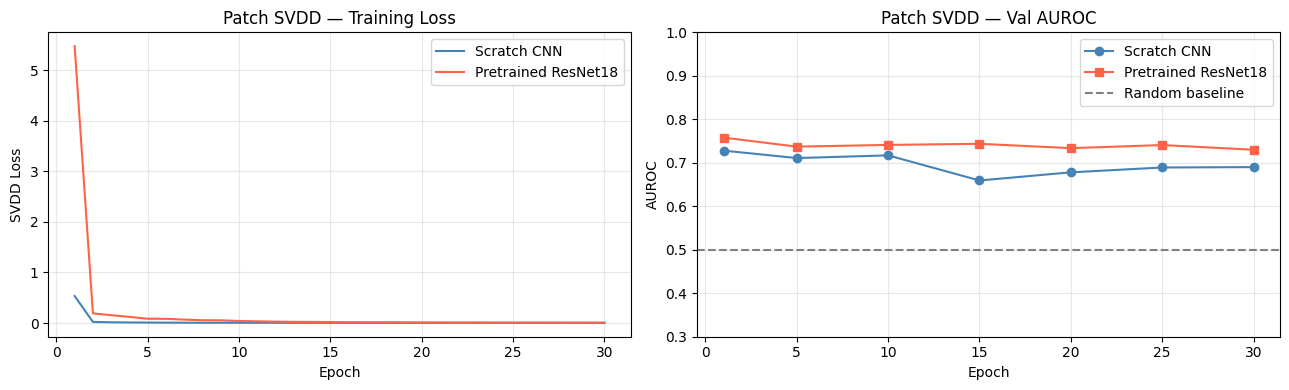

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Loss curves ──
axes[0].plot(range(1, len(losses_scratch) + 1),    losses_scratch,    color='steelblue', label='Scratch CNN')
axes[0].plot(range(1, len(losses_pretrained) + 1), losses_pretrained, color='tomato',    label='Pretrained ResNet18')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('SVDD Loss')
axes[0].set_title('Patch SVDD — Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Val AUROC ──
def unzip_aurocs(auroc_list):
    epochs, aurocs = zip(*auroc_list)
    return list(epochs), list(aurocs)

ep_s, au_s = unzip_aurocs(aurocs_scratch)
ep_p, au_p = unzip_aurocs(aurocs_pretrained)

axes[1].plot(ep_s, au_s, marker='o', color='steelblue', label='Scratch CNN')
axes[1].plot(ep_p, au_p, marker='s', color='tomato',    label='Pretrained ResNet18')
axes[1].axhline(0.5, color='grey', linestyle='--', label='Random baseline')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUROC')
axes[1].set_title('Patch SVDD — Val AUROC')
axes[1].set_ylim(0.3, 1.0)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/patch_svdd_curves.png', dpi=120, bbox_inches='tight')
plt.show()

### 8. Test Set Evaluation — Both Variants

In [23]:
def evaluate_patch_model(model, c, val_loader, test_loader, device, name):
    val_scores,  val_labels  = patch_svdd_scores(model, c, val_loader,  device)
    test_scores, test_labels = patch_svdd_scores(model, c, test_loader, device)
    threshold, _ = calibrate_threshold(val_scores, val_labels)
    metrics      = compute_metrics(test_scores, test_labels, threshold)
    print(f'── {name} ──────────────────────────────')
    print(f'  AUROC  : {metrics["auroc"]:.4f}')
    print(f'  AUPRC  : {metrics["auprc"]:.4f}')
    print(f'  F1     : {metrics["f1"]:.4f}')
    cm = metrics['cm']
    print(f'  TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}')
    return metrics, test_scores, test_labels


metrics_scratch,    scores_scratch,    labels_scratch    = evaluate_patch_model(
    model_scratch,    c_scratch,    val_loader, test_loader, device, 'Patch SVDD (Scratch CNN)')

metrics_pretrained, scores_pretrained, labels_pretrained = evaluate_patch_model(
    model_pretrained, c_pretrained, val_loader, test_loader, device, 'Patch SVDD (Pretrained ResNet18)')

# Save
torch.save({
    'scratch':    {'metrics': metrics_scratch,    'scores': scores_scratch},
    'pretrained': {'metrics': metrics_pretrained, 'scores': scores_pretrained},
    'labels': labels_scratch,
}, f'{RESULTS_DIR}/patch_svdd_results.pt')
print('\nResults saved to results/patch_svdd_results.pt')

── Patch SVDD (Scratch CNN) ──────────────────────────────
  AUROC  : 0.6853
  AUPRC  : 0.1936
  F1     : 0.2936
  TN=2628  FP=632  FN=215  TP=176
── Patch SVDD (Pretrained ResNet18) ──────────────────────────────
  AUROC  : 0.7067
  AUPRC  : 0.2178
  F1     : 0.3127
  TN=2399  FP=861  FN=159  TP=232

Results saved to results/patch_svdd_results.pt


### 9. Score Distribution & ROC Curves

TypeError: plot_roc_curve() missing 1 required positional argument: 'auroc'

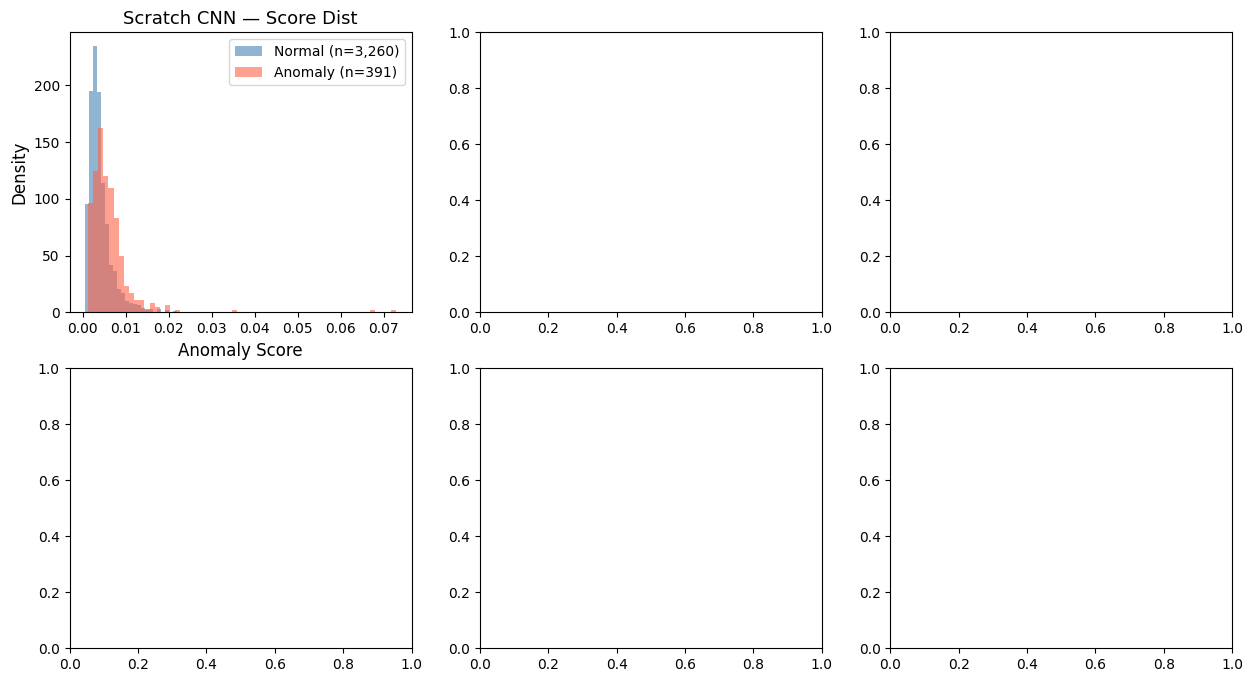

In [24]:
from src.viz_utils import plot_score_histogram, plot_roc_curve, plot_confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Row 0: Scratch CNN
plot_score_histogram(scores_scratch,    labels_scratch,    title='Scratch CNN — Score Dist',    ax=axes[0][0])
plot_roc_curve(      scores_scratch,    labels_scratch,    title='Scratch CNN — ROC',           ax=axes[0][1])
plot_confusion_matrix(metrics_scratch['confusion_matrix'],  title='Scratch CNN — Confusion',    ax=axes[0][2])

# Row 1: Pretrained ResNet18
plot_score_histogram(scores_pretrained, labels_pretrained, title='Pretrained ResNet18 — Score Dist', ax=axes[1][0])
plot_roc_curve(      scores_pretrained, labels_pretrained, title='Pretrained ResNet18 — ROC',        ax=axes[1][1])
plot_confusion_matrix(metrics_pretrained['confusion_matrix'], title='Pretrained ResNet18 — Confusion', ax=axes[1][2])

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/patch_svdd_eval.png', dpi=120, bbox_inches='tight')
plt.show()

### 10. Patch Score Heatmap — Pretrained ResNet18

Visualise which patches drove the anomaly score for sample test images.  
High-scoring patches should overlap with crack regions.

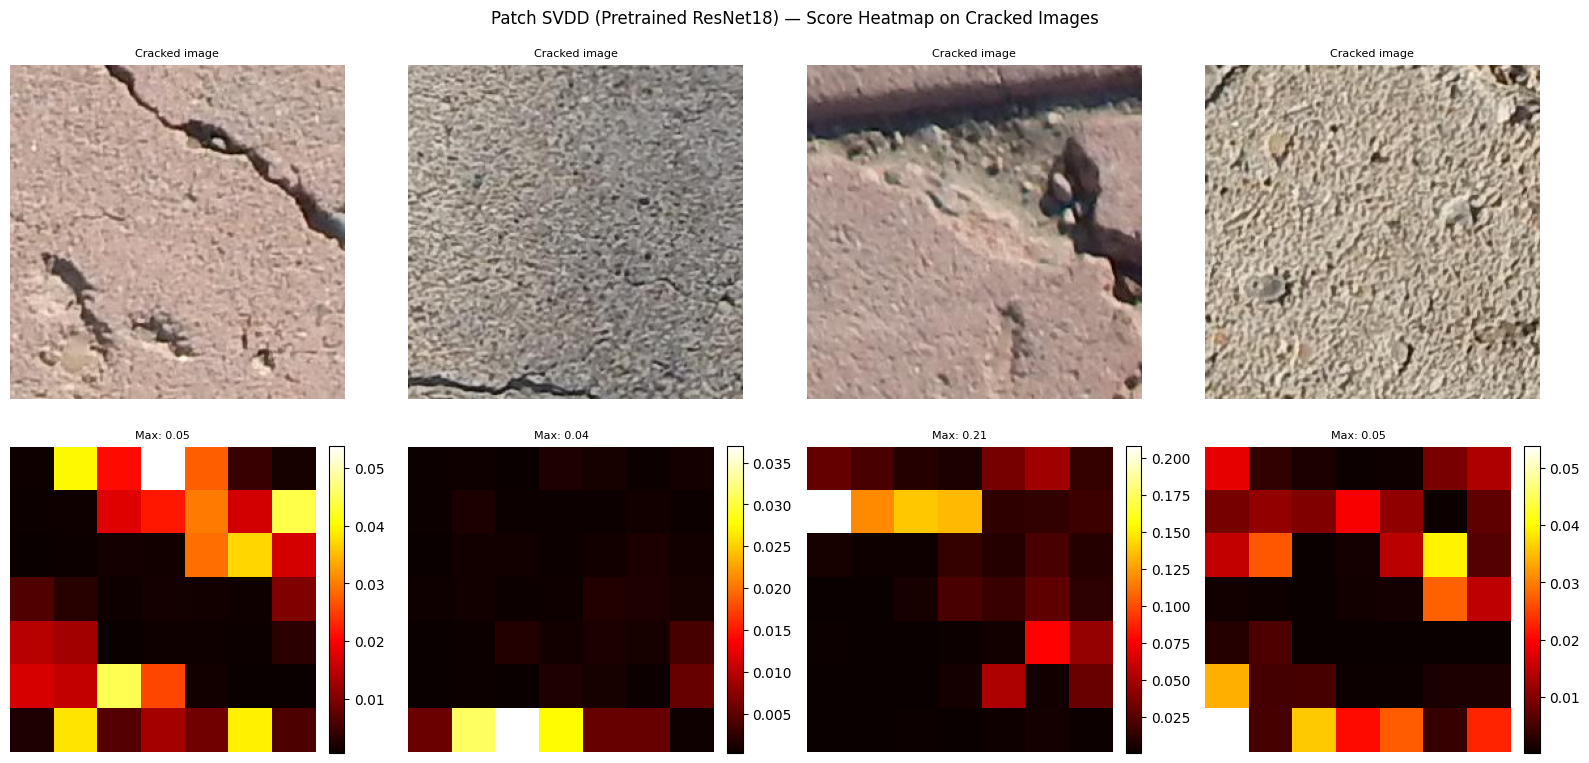

In [25]:
import random

def visualise_patch_scores(model, c, records, device,
                           patch_size=PATCH_SIZE, stride=STRIDE,
                           n_images=4, seed=0, title='Patch SVDD'):
    """Show original image overlaid with patch anomaly score heatmap."""
    model.eval()
    random.seed(seed)
    cracked = [r for r in records if r['label'] == 1]
    samples = random.sample(cracked, min(n_images, len(cracked)))

    fig, axes = plt.subplots(2, n_images, figsize=(4 * n_images, 8))
    fig.suptitle(f'{title} — Score Heatmap on Cracked Images', fontsize=12)

    for col, rec in enumerate(samples):
        img_pil = Image.open(rec['image_path']).convert('RGB')
        img_np  = np.array(img_pil)
        t       = _transform(img_pil)
        patches = extract_patches(t, patch_size, stride).to(device)
        with torch.no_grad():
            z     = model(patches)
            dists = ((z - c) ** 2).sum(dim=1).cpu().numpy()

        n_y = (256 - patch_size) // stride + 1
        n_x = (256 - patch_size) // stride + 1
        score_map = dists.reshape(n_y, n_x)

        axes[0][col].imshow(img_np)
        axes[0][col].set_title('Cracked image', fontsize=8)
        axes[0][col].axis('off')

        im = axes[1][col].imshow(score_map, cmap='hot', interpolation='nearest')
        axes[1][col].set_title(f'Max: {dists.max():.2f}', fontsize=8)
        axes[1][col].axis('off')
        plt.colorbar(im, ax=axes[1][col], fraction=0.046, pad=0.04)

    plt.tight_layout()
    return fig


# Show heatmap for pretrained model (more informative since it doesn't collapse)
fig = visualise_patch_scores(model_pretrained, c_pretrained, test_records, device,
                             title='Patch SVDD (Pretrained ResNet18)')
plt.savefig(f'{RESULTS_DIR}/patch_svdd_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

### 11. Comparison — Scratch vs Pretrained vs Image-level SVDD

Image-level SVDD results not found — run 1_improved_svdd.ipynb first
Patch SVDD (Scratch) AUROC : 0.6853
Patch SVDD (Pretrain) AUROC: 0.7067


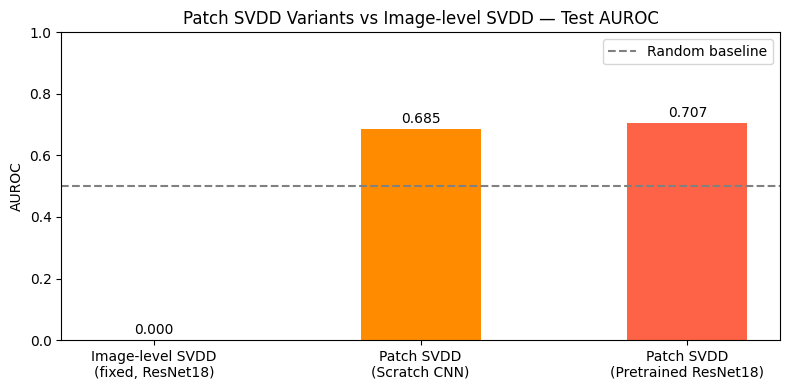

In [26]:
# Load image-level SVDD results if available
img_svdd_auroc = None
img_svdd_path  = f'{RESULTS_DIR}/svdd_fixed.pt'
if os.path.exists(img_svdd_path):
    saved = torch.load(img_svdd_path, map_location='cpu')
    img_svdd_auroc = saved['metrics']['auroc']
    print(f'Image-level SVDD AUROC     : {img_svdd_auroc:.4f}')
else:
    print('Image-level SVDD results not found — run 1_improved_svdd.ipynb first')
    img_svdd_auroc = 0.0

scratch_auroc    = metrics_scratch['auroc']
pretrained_auroc = metrics_pretrained['auroc']
print(f'Patch SVDD (Scratch) AUROC : {scratch_auroc:.4f}')
print(f'Patch SVDD (Pretrain) AUROC: {pretrained_auroc:.4f}')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
bar_labels = [
    'Image-level SVDD\n(fixed, ResNet18)',
    'Patch SVDD\n(Scratch CNN)',
    'Patch SVDD\n(Pretrained ResNet18)',
]
values  = [img_svdd_auroc, scratch_auroc, pretrained_auroc]
colours = ['steelblue', 'darkorange', 'tomato']
bars = ax.bar(bar_labels, values, color=colours, width=0.45)
ax.axhline(0.5, color='grey', linestyle='--', label='Random baseline')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('AUROC')
ax.set_ylim(0.0, 1.0)
ax.set_title('Patch SVDD Variants vs Image-level SVDD — Test AUROC')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/patch_vs_image_svdd.png', dpi=120, bbox_inches='tight')
plt.show()

## Results
Both patch-level SVDD variants outperform random guessing, with the pretrained ResNet18 version performing slightly better than the scratch CNN (0.7067 vs 0.6853 AUROC). This shows that moving from image-level to patch-level scoring does improve discrimination somewhat, likely because cracks are spatially localised and patch scoring preserves that signal better than a single global embedding.

## Issues
However, both models show the same collapse pattern: validation AUROC peaks at epoch 1 and then degrades, meaning training quickly destroys the initial feature spread that gives the best separation. Even with a frozen pretrained backbone, the projection head alone is enough to collapse the embedding space. This suggests that patch granularity helps, but does not fix the core SVDD optimisation problem.